In [16]:
import torch
import torch.nn as nn
import torch.optim as optim
import numpy as np
import pandas as pd
from dataloader import get_data
from sklearn.preprocessing import MinMaxScaler

In [17]:
df = pd.read_csv('sdi_1_24.csv')

df.columns = ['S2K_item_1', 'S2K_item_2', 'S2K_item_3', 'S2K_item_4', 'S2K_item_5',
       'S2K_item_6', 'S2K_item_7', 'S2K_item_8', 'S2K_item_9', 'S2K_item_10',
       'S2K_item_11', 'S2K_item_12', 'S2K_item_13', 'S2K_item_14',
       'S2K_item_15', 'S2K_item_16', 'S2K_item_17', 'S2K_item_18',
       'S2K_item_19', 'S2K_item_20', 'S2K_item_21', 'S2K_item_22',
       'S2K_item_23', 'S2K_item_24']

In [18]:
df = df.astype('float32')
dataset, dataloader = get_data(df)

In [19]:
input_dim = 100
output_dim = dataset.shape()[1]
device = torch.device("cuda:0" if torch.cuda.is_available() else "cpu")

In [20]:
class Generator(nn.Module):
    def __init__(self, input_dim, output_dim):
        super().__init__()
        self.model = nn.Sequential(
            nn.Linear(input_dim, 128),
            nn.ReLU(True),
            nn.Linear(128, 256),
            nn.ReLU(True),
            nn.Linear(256, 512),
            nn.ReLU(True),
            nn.Linear(512, output_dim),
            nn.ReLU(True)
        )

    def forward(self, x):
        return self.model(x)


In [21]:
class Discriminator(nn.Module):
    def __init__(self, input_dim):
        super().__init__()
        self.model = nn.Sequential(
            nn.Linear(input_dim, 512),
            nn.LeakyReLU(0.2, inplace=True),
            nn.Linear(512, 256),
            nn.LeakyReLU(0.2, inplace=True),
            nn.Linear(256, 128),
            nn.LeakyReLU(0.2, inplace=True),
            nn.Linear(128, 1),
            nn.Sigmoid()
        )

    def forward(self, x):
        return self.model(x)


In [22]:
generator = Generator(input_dim, output_dim).to(device)
discriminator = Discriminator(output_dim).to(device)


print(f"Generator model initialized with input_dim={input_dim} and moved to {device}.")
print(f"Discriminator model initialized and moved to {device}.")


Generator model initialized with input_dim=100 and moved to cpu.
Discriminator model initialized and moved to cpu.


In [23]:
criterion = nn.BCELoss()
lr = 2e-5

optimizer_g = optim.Adam(generator.parameters(), lr=lr)
optimizer_d = optim.Adam(discriminator.parameters(), lr=lr)

num_epochs = 50
batch_size = 64

In [24]:
for epoch in range(num_epochs):
    for i, (real_samples, _) in enumerate(dataloader):
        batch_size = real_samples.size(0)
        real_samples = real_samples.to(device)


        # Adversarial ground truths
        valid = torch.ones(batch_size, 1, requires_grad=False).to(device)
        fake = torch.zeros(batch_size, 1, requires_grad=False).to(device)


        # ---------------------
        #  Train Discriminator
        # ---------------------

        optimizer_d.zero_grad()

        # Noise
        z = torch.randn(batch_size, input_dim).to(device)

        # Batch Generation
        gen_samples = generator(z)

        # Loss 
        real_loss = criterion(discriminator(real_samples), valid)
        fake_loss = criterion(discriminator(gen_samples.detach()), fake)
        d_loss = real_loss + fake_loss

        d_loss.backward()
        optimizer_d.step()

        # -----------------
        #  Train Generator
        # -----------------

        optimizer_g.zero_grad()

        # Loss
        g_loss = criterion(discriminator(gen_samples), valid)

        g_loss.backward()
        optimizer_g.step()


        if i % 100 == 0:
            print(f"[Epoch {epoch}/{num_epochs}] [Batch {i}/{len(dataloader)}] [D loss: {d_loss.item()}] [G loss: {g_loss.item()}]")

[Epoch 0/50] [Batch 0/38] [D loss: 1.3879315853118896] [G loss: 0.6997381448745728]
[Epoch 1/50] [Batch 0/38] [D loss: 1.3784693479537964] [G loss: 0.7028282880783081]
[Epoch 2/50] [Batch 0/38] [D loss: 1.3755372762680054] [G loss: 0.7027338743209839]
[Epoch 3/50] [Batch 0/38] [D loss: 1.3747798204421997] [G loss: 0.7009838819503784]
[Epoch 4/50] [Batch 0/38] [D loss: 1.3680064678192139] [G loss: 0.7039709687232971]
[Epoch 5/50] [Batch 0/38] [D loss: 1.349244475364685] [G loss: 0.7132890224456787]
[Epoch 6/50] [Batch 0/38] [D loss: 1.341712474822998] [G loss: 0.7082734107971191]
[Epoch 7/50] [Batch 0/38] [D loss: 1.3513357639312744] [G loss: 0.693332850933075]
[Epoch 8/50] [Batch 0/38] [D loss: 1.3321154117584229] [G loss: 0.7101015448570251]
[Epoch 9/50] [Batch 0/38] [D loss: 1.3622417449951172] [G loss: 0.7155921459197998]
[Epoch 10/50] [Batch 0/38] [D loss: 1.3622111082077026] [G loss: 0.7237907648086548]
[Epoch 11/50] [Batch 0/38] [D loss: 1.2836670875549316] [G loss: 0.80983507633

In [25]:
torch.save(generator.state_dict(), 'generator.pth')
torch.save(discriminator.state_dict(), 'discriminator.pth')

In [32]:
num_samples = 200
noise_vectors = torch.randn(num_samples, input_dim).to(device)

with torch.no_grad():
    gen_samples = generator(noise_vectors)

gen_samples = gen_samples.cpu().numpy()
gen_df = pd.DataFrame(gen_samples)
gen_df.columns = df.columns

In [33]:
cols = ['S2K_item_1', 'S2K_item_2', 'S2K_item_3', 'S2K_item_4', 'S2K_item_5',
       'S2K_item_6', 'S2K_item_7', 'S2K_item_8', 'S2K_item_9', 'S2K_item_10',
       'S2K_item_11', 'S2K_item_12', 'S2K_item_13', 'S2K_item_14',
       'S2K_item_15', 'S2K_item_16', 'S2K_item_17', 'S2K_item_18',
       'S2K_item_19', 'S2K_item_20', 'S2K_item_21', 'S2K_item_22',
       'S2K_item_23', 'S2K_item_24']
ranges = []

for col in cols:
    ranges.append(list(gen_df[col].unique()))
    print(f'Column: {col} - {gen_df[col].unique()}')

Column: S2K_item_1 - [0.]
Column: S2K_item_2 - [0.]
Column: S2K_item_3 - [0.]
Column: S2K_item_4 - [0.]
Column: S2K_item_5 - [0.]
Column: S2K_item_6 - [0.]
Column: S2K_item_7 - [0.]
Column: S2K_item_8 - [0.]
Column: S2K_item_9 - [0.         0.02916829]
Column: S2K_item_10 - [0.]
Column: S2K_item_11 - [0.]
Column: S2K_item_12 - [0.]
Column: S2K_item_13 - [0.         0.00463867 0.00258009 0.00481457 0.00356802 0.00175403]
Column: S2K_item_14 - [0.]
Column: S2K_item_15 - [0.]
Column: S2K_item_16 - [0.         0.01594027]
Column: S2K_item_17 - [0.         0.00236618]
Column: S2K_item_18 - [0.]
Column: S2K_item_19 - [0.         0.01308981 0.01507759]
Column: S2K_item_20 - [0.]
Column: S2K_item_21 - [0.08623722 0.09237806 0.13769382 0.11852943 0.03546534 0.06261799
 0.10018282 0.1211878  0.07711089 0.10638817 0.11471397 0.04598373
 0.03942476 0.08679243 0.06798857 0.07434864 0.12591782 0.07335758
 0.11695844 0.08041817 0.16808608 0.10532878 0.08922158 0.1098569
 0.10839944 0.13907894 0.11777

In [34]:
gen_df = gen_df.apply(lambda x: np.ceil(x))

In [35]:
# def find_closest_threshold(number, thresholds):
#     closest_threshold = min(thresholds, key=lambda x: abs(x - number))
#     return closest_threshold


# for idx, col in enumerate(cols):
#     gen_df[col] = [find_closest_threshold(num, ranges[idx]) for num in gen_df[col].values]

# gen_df


In [53]:
gen_df.to_csv('gen_sdi_1.csv', index=False)

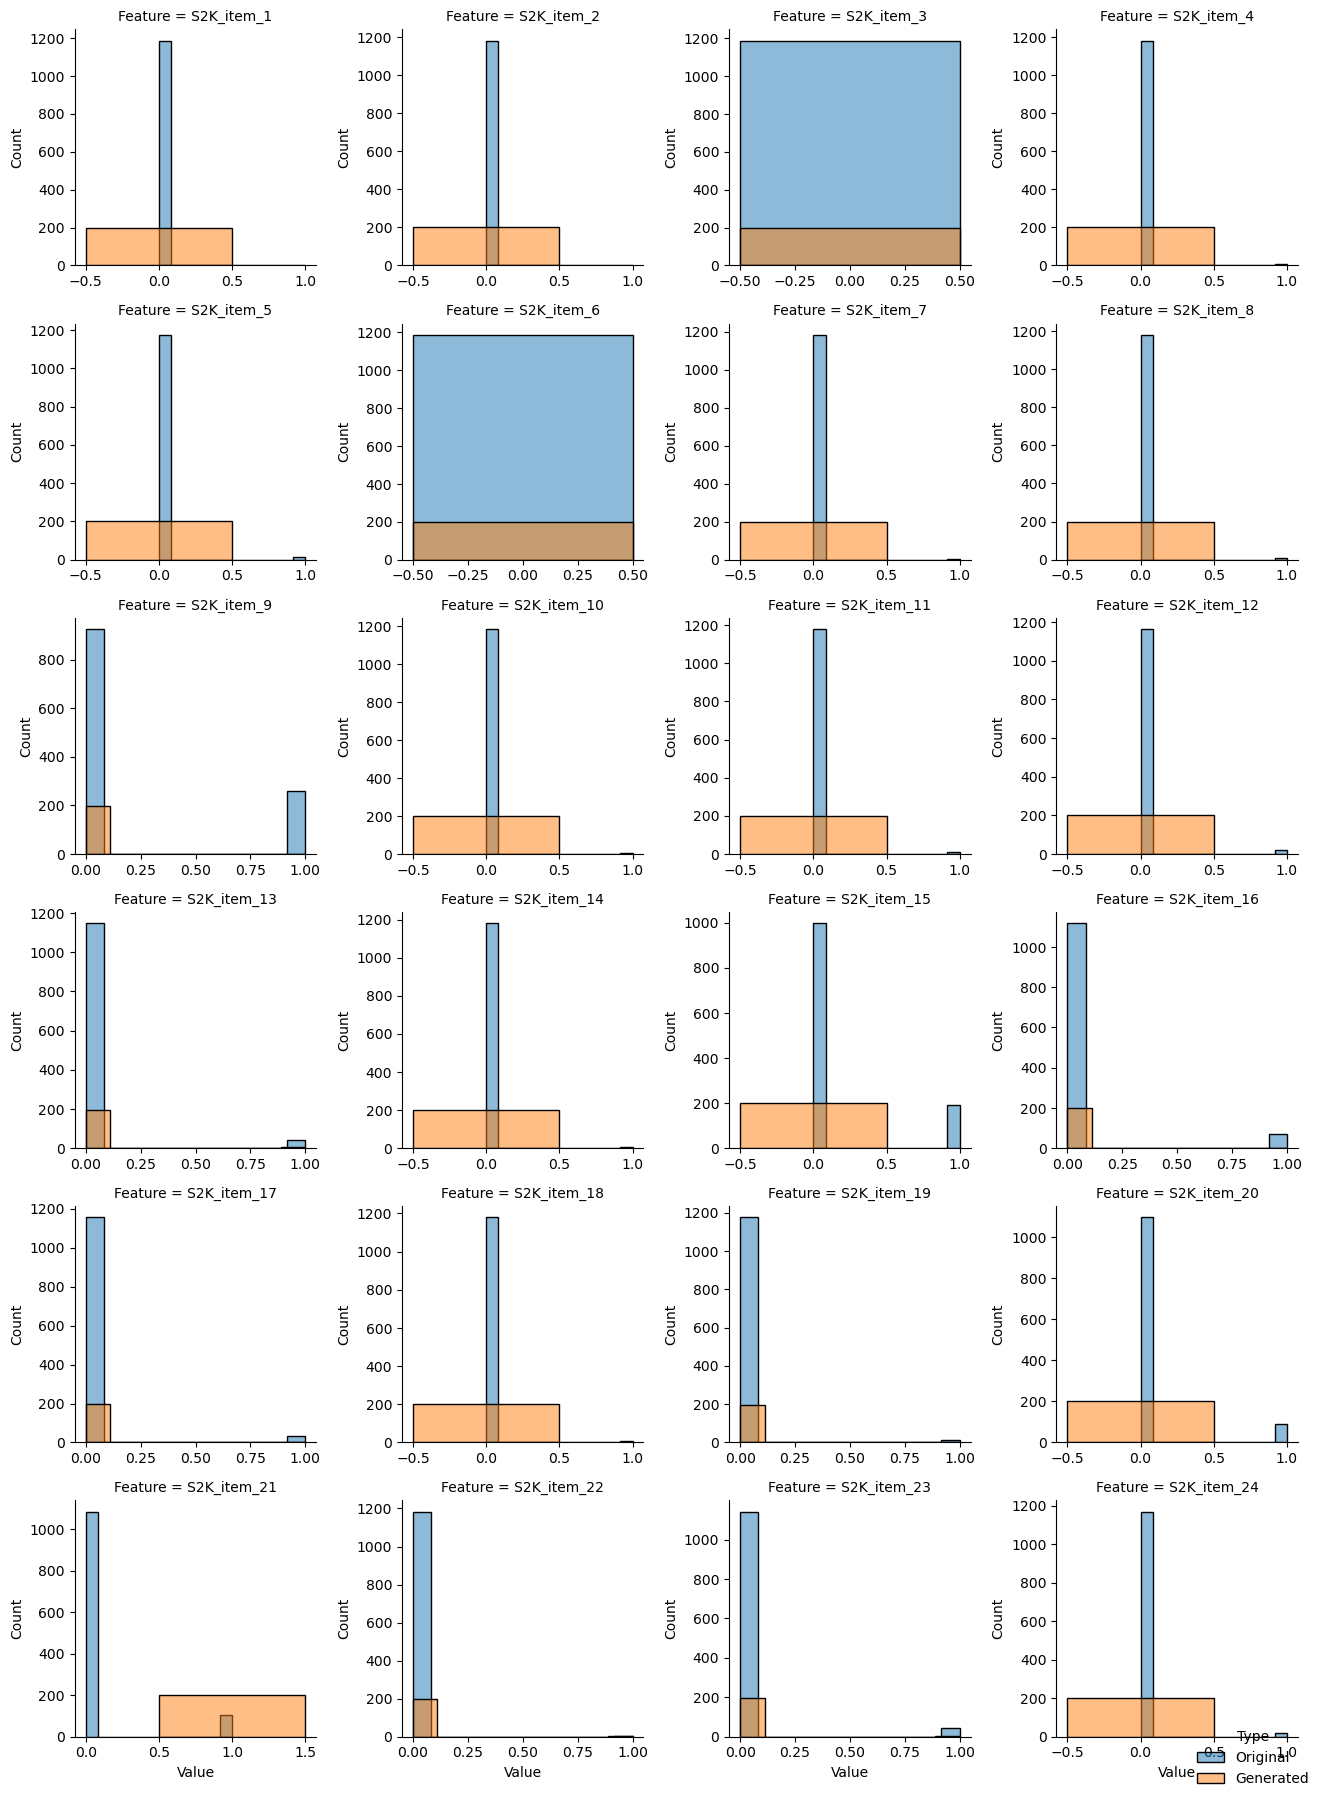

In [52]:
import seaborn as sns
import matplotlib.pyplot as plt

df['Type'] = 'Original'
gen_df['Type'] = 'Generated'

combined_df = pd.concat([df, gen_df])

melted_df = combined_df.melt(id_vars='Type', var_name='Feature', value_name='Value')

g = sns.FacetGrid(melted_df, col="Feature", hue="Type", col_wrap=4, sharex=False, sharey=False, height=3)
g.map(sns.kdeplot, 'Value', fill=True, common_norm=True, alpha=0.5)
g.add_legend(loc='lower right')

plt.tight_layout()
plt.show()
